In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from bev_generation.unet import Unet_BEVGenerator

model = Unet_BEVGenerator()


In [ ]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="expert-data",
        unet=True),
        batch_size=4,
        shuffle=True,
    )

In [ ]:

for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    bev = model.infer(expert_obs_dict)
    if i == 0:
        break

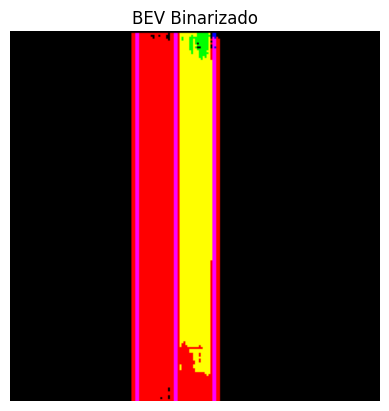

In [ ]:
import matplotlib.pyplot as plt

bev_img = bev[3].detach().cpu()

# binariza
bev_bin = (bev_img > 0.5).float()

# plot
import matplotlib.pyplot as plt

bev_plot = bev_bin.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

In [ ]:
bev_bin = (bev > 0.5)

### Teste evaluation

In [ ]:
import numpy as np
import torch
import cv2
from PIL import Image
from expert_dataset_def.expert_dataset import traj_plotter, traj_plotter_rgb
import pandas as pd
import os

def create_image_tensor(obs, unet=False, w_resize=192, h_resize=192):
    """
    Prepara tensor de entrada para a UNet.
    Gera o traj_plot internamente a partir das coordenadas brutas em obs['traj'].
    """
    def process_image(image: np.ndarray, traj=False):
        # Garante que estamos trabalhando com numpy array
        if isinstance(image, torch.Tensor):
            image = image.cpu().numpy()
        
        if image.ndim == 4:
            image = image[0]  # Remove batch dim se existir

        if not traj:
            # Imagens das câmeras vêm como (H, W, 3) do PIL/numpy
            # Redimensiona primeiro mantendo formato HWC
            image = cv2.resize(image, (w_resize, h_resize),interpolation=cv2.INTER_NEAREST)  # (H, W, 3)
            # Converte para CHW para o tensor PyTorch
            image = image.transpose(2, 0, 1)  # (3, H, W)
        else:
            # traj_plot: pode vir como (H, W) ou (1, H, W)
            if image.ndim == 3 and image.shape[0] == 1:
                image = image[0]  # Remove channel dim extra se existir
            image = cv2.resize(image, (w_resize, h_resize),interpolation=cv2.INTER_NEAREST)  # (H, W)
            image = image[None, :, :]  # (1, H, W)

        return torch.as_tensor(image, dtype=torch.float32) / 255.0

    image_tensor_list = []
    

    # GERAÇÃO DO TRAJ_PLOT DENTRO DA FUNÇÃO
    if unet:
        camera_order = ["central_rgb", "left_rgb", "right_rgb", "rear_rgb"]
        # traj_plotter retorna tensor (1, H, W) em [0, 255]
        traj_tensor = traj_plotter(obs['traj'], w_resize, h_resize)
        traj_plot = traj_tensor / 255.0  # Normaliza para [0, 1]
    else:
        camera_order = ["left_rgb", "central_rgb", "right_rgb", "rear_rgb"]
        # traj_plotter_rgb retorna tensor (3, H, W) em [0, 255]
        traj_tensor = traj_plotter_rgb(obs['traj'], w_resize, h_resize)
        traj_plot = traj_tensor / 255.0
    
    for i in camera_order:
        image_tensor_list.append(process_image(obs[i]))

    image_tensor_list.append(traj_plot)
    images = torch.cat(image_tensor_list, dim=0)  # Concatena ao longo dos canais: 4*3 + 1 = 13
    return images.unsqueeze(0)  # Adiciona batch dim: (1, 13, 192, 192)

def load_cam(path):
    return np.array(Image.open(path).convert('RGB'))

In [ ]:
caminho_rota = "/home/felipe_cds/carla-bc-bev/expert-data/route_00/ep_00"
json_path = os.path.join(caminho_rota, 'episode.json')
frame_idx = 133
df = pd.read_json(json_path)
obs = {
    'left_rgb': load_cam(os.path.join(caminho_rota, 'left_rgb', f'{frame_idx:04d}.png')),
    'central_rgb': load_cam(os.path.join(caminho_rota, 'central_rgb', f'{frame_idx:04d}.png')),
    'right_rgb': load_cam(os.path.join(caminho_rota, 'right_rgb', f'{frame_idx:04d}.png')),
    'rear_rgb': load_cam(os.path.join(caminho_rota, 'rear_rgb', f'{frame_idx:04d}.png')),
    'traj': df['traj'].iloc[frame_idx],  # Passa coordenadas brutas
}
        
        # Prepara tensor para inferência e roda a UNet
inp_tensor = create_image_tensor(obs, unet=True).to("cuda")
        

In [ ]:
bev_geneated = model.infer({'image': inp_tensor})

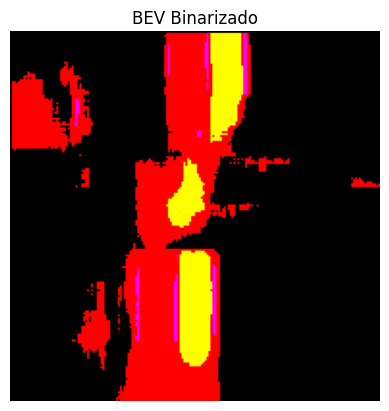

In [ ]:
import matplotlib.pyplot as plt

bev_img = bev_geneated[0].detach().cpu()

# binariza
bev_bin = (bev_img > 0.5).float()


bev_plot = bev_bin.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

## CVT

In [ ]:
from bev_generation.cvt_3ch import CVT_3chL1Generator

model = CVT_3chL1Generator(device='cuda')

Loaded pretrained weights for efficientnet-b4


In [ ]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="expert-data",
        unet=False),
        batch_size=4,
        shuffle=True,
    )

In [ ]:

for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    bev = model.infer(expert_obs_dict)
    if i == 0:
        break

In [ ]:
bev.min()

tensor(-0.0211)

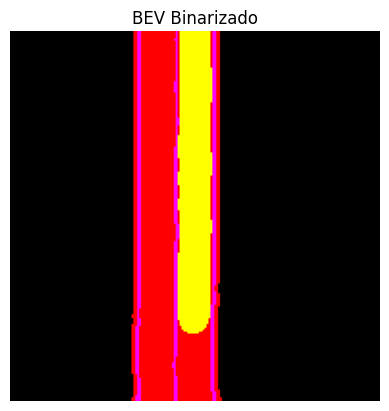

In [ ]:
import matplotlib.pyplot as plt

bev_img = bev[3].detach().cpu()

# binariza
#bev_bin = (bev_img > 0.5).float()


bev_plot = bev_img.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

In [ ]:
from bev_generation.cvt_6ch import CVT_6chVanilla
bev_generator = CVT_6chVanilla(device="cuda")

Loaded pretrained weights for efficientnet-b4


In [ ]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="expert-data",
        unet=tru,
        sizes=(480,224,256)),
        batch_size=4,
        shuffle=False,
    )

In [ ]:
for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    bev = bev_generator.infer(expert_obs_dict)
    if i == 0:
        break

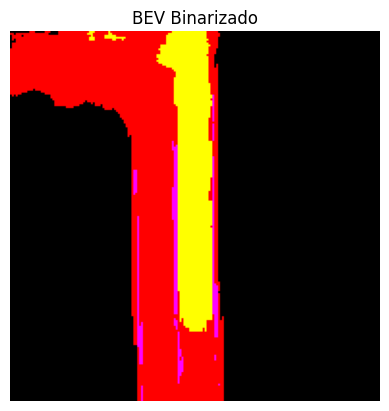

In [ ]:
import matplotlib.pyplot as plt

bev_img = bev[3].detach().cpu()

# binariza
#bev_bin = (bev_img > 0.5).float()


bev_plot = bev_img.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

## Unet 

In [7]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th


dataloader = th.utils.data.DataLoader(
        dataset = ExpertDataset(
        dataset_directory="/home/felipe_cds/unet/expert_data_balanced",
        unet=True),
        batch_size=4,
        shuffle=False,
    )

In [8]:
from bev_generation.unet import Unet_BEVGenerator
bev_generator = Unet_BEVGenerator(device="cuda")

In [13]:
for i,expert_batch in enumerate(dataloader):
    expert_obs_dict, expert_action = expert_batch
    #print(expert_obs_dict['image'].shape)
    bev = bev_generator.infer(expert_obs_dict)
    if i == 0:
        break

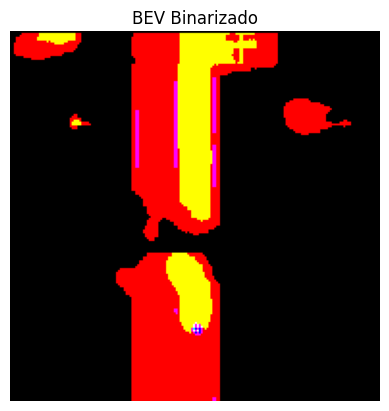

In [15]:
import matplotlib.pyplot as plt

bev_img = bev[0].detach().cpu()

# binariza
#bev_bin = (bev_img > 0.5).float()


bev_plot = bev_img.permute(1, 2, 0).numpy()

plt.imshow(bev_plot)
plt.title("BEV Binarizado")
plt.axis('off')
plt.show()

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Optional, List

def plot_batch_inputs(
    batch: torch.Tensor,
    batch_idx: int = 0,
    channel_names: Optional[List[str]] = None,
    denormalize: bool = True,
    save_path: Optional[str] = None,
    figsize: tuple = (15, 8),
    verbose: bool = True
) -> plt.Figure:
    """
    Plota as imagens de entrada de um batch no formato (B, 13, H, W).
    
    Estrutura esperada dos 13 canais:
    - central_rgb: canais 0-2  | left_rgb: 3-5  | right_rgb: 6-8  
    - rear_rgb:    canais 9-11 | traj_plot: 12
    
    Args:
        batch: Tensor de shape (B, 13, H, W)
        batch_idx: Índice do item no batch para plotar (default: 0)
        channel_names: Lista opcional de nomes para as 5 "imagens"
        denormalize: Se True, assume valores em [0,1] e escala para [0,255] para exibição
        save_path: Se fornecido, salva a figura neste caminho
        figsize: Tamanho da figura matplotlib
        verbose: Se True, imprime shape e estatísticas das imagens
    
    Returns:
        Figura matplotlib com as imagens plotadas
    """
    if channel_names is None:
        channel_names = ['central_rgb', 'left_rgb', 'right_rgb', 'rear_rgb', 'traj_plot']
    
    # Garantir que está na CPU e em numpy
    if isinstance(batch, torch.Tensor):
        img = batch[batch_idx].detach().cpu().numpy()  # (13, H, W)
        original_tensor = batch[batch_idx].detach()
    else:
        img = batch[batch_idx]
        original_tensor = torch.from_numpy(img)
    
    H, W = img.shape[-2:]
    
    # Mapeamento: (start_idx, nome, num_channels, is_grayscale)
    channel_map = [
        (0, channel_names[0], 3, False),
        (3, channel_names[1], 3, False),
        (6, channel_names[2], 3, False),
        (9, channel_names[3], 3, False),
        (12, channel_names[4], 1, True),
    ]
    
    # 📊 PRINT DE ESTATÍSTICAS
    if verbose:
        print(f"\n{'='*60}")
        print(f"📦 Batch item #{batch_idx} | Tensor shape: {tuple(batch[batch_idx].shape)}")
        print(f"{'='*60}")
        print(f"{'Canal':<15} {'Shape':<12} {'Min':>8} {'Max':>8} {'Mean':>8}")
        print(f"{'-'*60}")
        
        for start_idx, name, n_channels, is_gray in channel_map:
            if n_channels == 1:
                channel_data = original_tensor[start_idx]
                shape_str = f"(1, {H}, {W})"
            else:
                channel_data = original_tensor[start_idx:start_idx + n_channels]
                shape_str = f"({n_channels}, {H}, {W})"
            
            min_val = channel_data.min().item()
            max_val = channel_data.max().item()
            mean_val = channel_data.mean().item()
            
            print(f"{name:<15} {shape_str:<12} {min_val:8.4f} {max_val:8.4f} {mean_val:8.4f}")
        
        # Estatísticas globais
        print(f"{'-'*60}")
        print(f"{'TOTAL (13 canais)':<15} {'(13, %d, %d)'%(H,W):<12} "
              f"{original_tensor.min().item():8.4f} {original_tensor.max().item():8.4f} "
              f"{original_tensor.mean().item():8.4f}")
        print(f"{'='*60}\n")
    
    # Desnormalizar para visualização (se necessário)
    img_display = img.copy()
    if denormalize:
        if img.max() <= 1.0 and img.min() >= 0.0:
            img_display = img * 255.0
        img_display = np.clip(img_display, 0, 255).astype(np.uint8)
    
    # Criar figura
    fig, axes = plt.subplots(1, 5, figsize=figsize)
    fig.suptitle(f'Batch item #{batch_idx} - Input Channels\nShape: {tuple(batch[batch_idx].shape)}', 
                 fontsize=12, fontweight='bold')
    
    for start_idx, name, n_channels, is_gray in channel_map:
        if n_channels == 1:
            subplot_img = img_display[start_idx]
        else:
            subplot_img = np.transpose(img_display[start_idx:start_idx + n_channels], (1, 2, 0))
        
        idx = channel_map.index((start_idx, name, n_channels, is_gray))
        ax = axes[idx]
        
        if is_gray:
            ax.imshow(subplot_img, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(subplot_img)
        
        # Título com stats resumidos
        if n_channels == 1:
            ch_data = original_tensor[start_idx]
        else:
            ch_data = original_tensor[start_idx:start_idx + n_channels]
        min_v, max_v = ch_data.min().item(), ch_data.max().item()
        ax.set_title(f"{name}\n[{min_v:.2f}, {max_v:.2f}]", fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Figura salva em: {save_path}")
    
    return fig


📦 Batch item #0 | Tensor shape: (13, 192, 192)
Canal           Shape             Min      Max     Mean
------------------------------------------------------------
central_rgb     (3, 192, 192)   0.0000   0.9882   0.5809
left_rgb        (3, 192, 192)   0.0000   0.9922   0.6176
right_rgb       (3, 192, 192)   0.0000   0.9882   0.3976
rear_rgb        (3, 192, 192)   0.0000   1.0000   0.4534
traj_plot       (1, 192, 192)   0.0000   1.0000   0.0214
------------------------------------------------------------
TOTAL (13 canais) (13, 192, 192)   0.0000   1.0000   0.4746



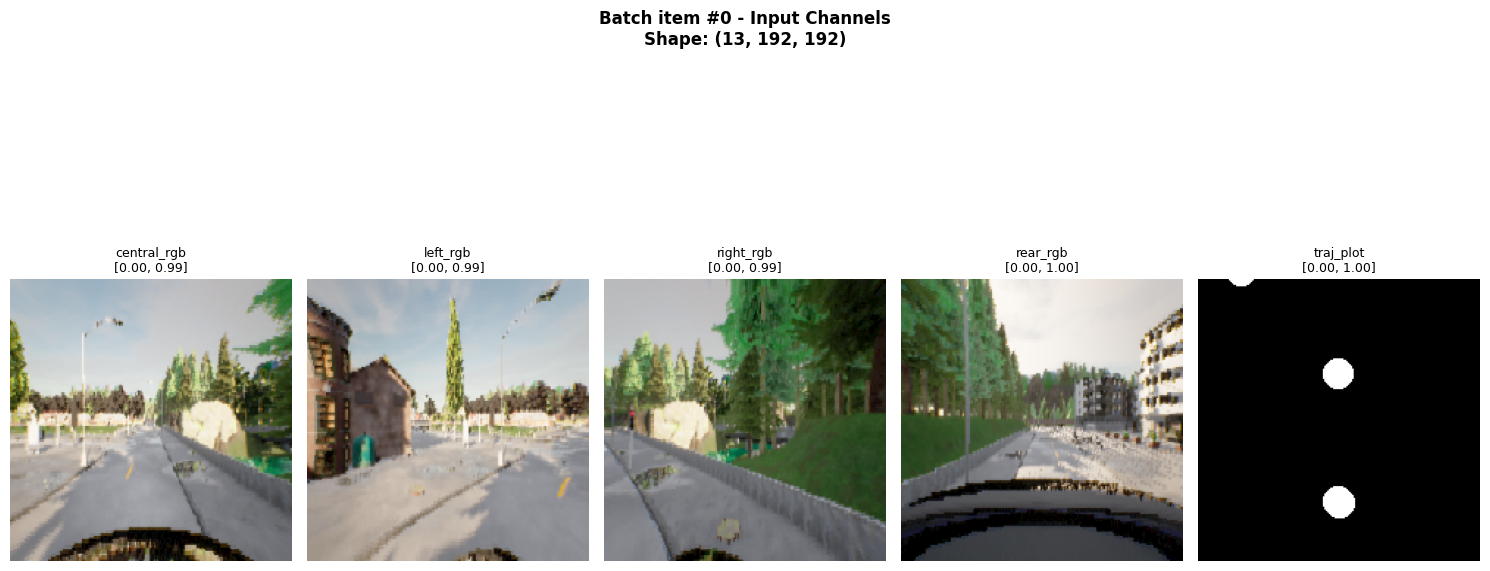

In [17]:
plot_batch_inputs(expert_obs_dict['image'], batch_idx=0)
plt.show()